In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

from scipy.signal import welch
from scipy.optimize import curve_fit

from scipy.fft import rfft, irfft, rfftfreq

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215/../../analysis_utils.py'>

In [3]:
def read_recon(dataset, voltages):
    file = rf'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/pulse_calibration/{dataset}_processed.hdf5'

    amps_all, pulse_shapes_all, indices_in_win, zz_pulses_all, drive_area_all, f_res_all = [], [], [], [], [], []
    f = h5py.File(file, 'r')
    for v in voltages:
        amps = f['data_processed'][f'amplitudes_{v}v'][:]
        ps = f['data_processed'][f'pulse_shapes_{v}v'][:]
        indices = f['data_processed'][f'pulse_indices_in_win_{v}v'][:]
        zz = f['data_processed'][f'z_signal_{v}v'][:]
        drive_area = f['data_processed'][f'drive_area_{v}v'][:]
        f_res = f['data_processed'][f'f_res_{v}v'][:]

        amps_all.append(amps)
        pulse_shapes_all.append(ps)
        indices_in_win.append(indices)
        zz_pulses_all.append(zz)
        drive_area_all.append(drive_area)
        f_res_all.append(f_res)

    amps_noise = f['data_processed'][f'amplitudes_noise_2.5v'][:]
    amps_noise_search = f['data_processed'][f'amplitudes_noise_search_2.5v'][:]
    f.close()

    return amps_all, amps_noise, amps_noise_search, pulse_shapes_all, indices_in_win, zz_pulses_all, drive_area_all, f_res_all

def plot_monitoring(dataset, drive_area_all, amps_all, f_res_all, drive_freq, ref_freq, amp2kev):
    cmap = plt.colormaps.get_cmap('viridis')
    colors = cmap(np.linspace(0.2, 0.9, 8))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for i in range(8):
        norm = drive_area_all[i] * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        axes[0].plot(norm, amps_all[i]*amp2kev, '.', color=colors[i], markersize=3.5)

    _drive = np.concatenate(drive_area_all)
    _freq = np.concatenate(f_res_all)

    drive_freq = 137000
    ref_freq = 48500
    normalized_drive_area = _drive * (_freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)

    bins = np.linspace(0, normalized_drive_area.max() * 1.1, 150)
    bc = 0.5 * (bins[1:] + bins[:-1])

    hh, _ = np.histogram(normalized_drive_area, bins=bins)
    axes[1].errorbar(bc, hh, yerr=np.sqrt(hh), fmt='.', color='b', alpha=1)

    axes[0].set_xlim(0, 2e-8)
    axes[0].set_ylim(0, 1600)
    axes[0].set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a. u.)')
    axes[0].set_ylabel(r'Recon. amp. (keV/c)')

    axes[1].set_ylim(5e-1, 5e2)
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'Normalized driven $\langle z^2 \rangle$ (a. u.)')
    axes[1].set_ylabel(rf'Counts/({bc[1]-bc[0]:.1e} V$^2$)')

    fig.suptitle(dataset, fontsize=12)
    fig.tight_layout()

    return fig, axes, bc, hh


#### Plot the calibration waveforms and integrate for amplitude

In [4]:
def get_pulse_area(tt, dd):
    # Time in s, drive signal in V
    noise = np.mean(dd[tt < -0.5e-7])
    area = np.trapz(dd-noise, x=tt)
    
    return area

def process_pulse_waveforms(files):
    tt = None
    dds, aas = [], []
    for file in files:
        data = np.genfromtxt(file, delimiter=',', skip_header=1)
        _tt, _dd = data.T[0], data.T[1]
        _aa = get_pulse_area(_tt, _dd)

        if tt is None:
            tt = _tt

        dds.append(_dd)
        aas.append([_aa])

    return tt, dds, aas

# folder = r'E:\pulse_waveform\20241204_quantum_composers'
folder = r'/Volumes/LaCie/pulse_waveform/20241204_quantum_composers'

tt = None
dds_mean, dds_std, aas_mean, aas_std = [], [], [], []

for dataset in ['2_5v', '5v', '7_5v', '10v', '12_5v', '15v', '17_5v', '20v']:
    files = glob.glob(os.path.join(folder, f'{dataset}/C3_*.CSV'))
    _tt, dds, aas = process_pulse_waveforms(files)
    
    mean = np.mean(dds, axis=0)
    std = np.std(dds, axis=0)

    aa_mean = np.mean(aas)
    aa_std  = np.std(aas)

    if tt is None:
        tt = _tt

    dds_mean.append(mean)
    aas_mean.append(aa_mean)
    dds_std.append(std)
    aas_std.append(aa_std)

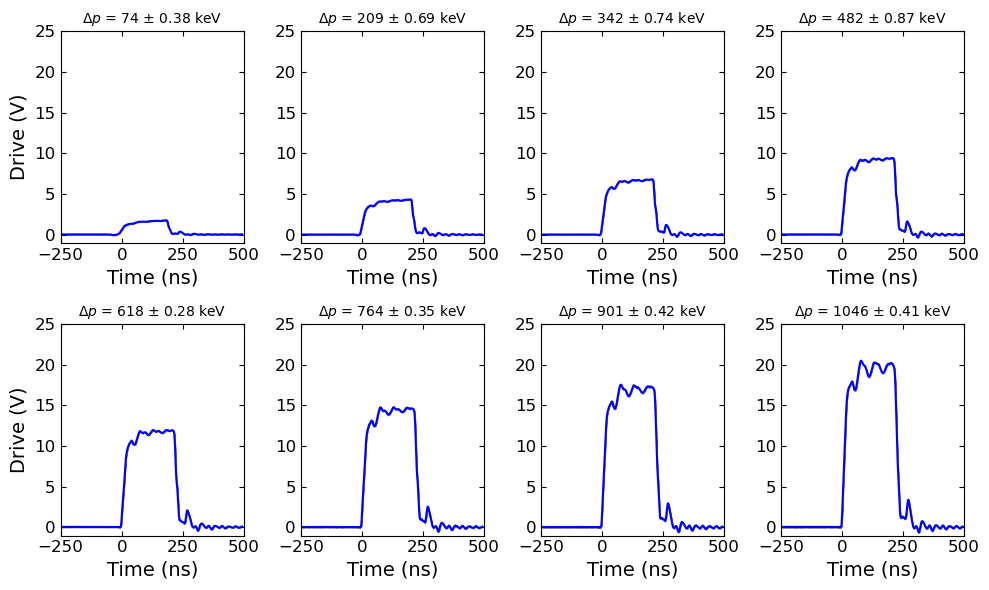

In [5]:
charge = 6
efield = 138 # V/m

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
for i in range(8):
    ax = axes.flatten()[i]

    amp_kev = charge * aas_mean[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    amp_kev_std = charge * aas_std[i] * efield * 1.602e-19 * utils.SI2ev / 1000
    
    ax.fill_between(tt*1e9, dds_mean[i]-dds_std[i], dds_mean[i]+dds_std[i], color='grey', alpha=0.95)
    ax.plot(tt*1e9, dds_mean[i], color='blue')
    
    ax.set_title(fr'$\Delta p$ = {int(amp_kev)} $\pm$ {amp_kev_std:.2f} keV', fontsize=10)

    ax.set_xlim(-250, 500)
    ax.set_ylim(-1, 25)
    
    if i == 0 or i == 4:
        ax.set_ylabel('Drive (V)')

    ax.set_xlabel('Time (ns)')

fig.tight_layout()

In [6]:
dataset_0 = '20260219_p6e_4e-8mbar_d137khz_0'
dataset_1 = '20260219_p6e_4e-8mbar_d137khz_1_afterxe'
dataset_2 = '20260219_p6e_4e-8mbar_d137khz_2_afterkr'
dataset_3 = '20260219_p6e_4e-8mbar_d137khz_3_aftersf6'
datasets_all = [dataset_0, dataset_1, dataset_2, dataset_3]

voltages = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]

amps_all_0, amps_noise_0, amps_noise_search_0, pulse_shapes_all_0, indices_0, zz_pulses_all_0, drive_area_all_0, f_res_all_0 = read_recon(dataset_0, voltages=voltages)
amps_all_1, amps_noise_1, amps_noise_search_1, pulse_shapes_all_1, indices_1, zz_pulses_all_1, drive_area_all_1, f_res_all_1 = read_recon(dataset_1, voltages=voltages)
amps_all_2, amps_noise_2, amps_noise_search_2, pulse_shapes_all_2, indices_2, zz_pulses_all_2, drive_area_all_2, f_res_all_2 = read_recon(dataset_2, voltages=voltages)
amps_all_3, amps_noise_3, amps_noise_search_3, pulse_shapes_all_3, indices_3, zz_pulses_all_3, drive_area_all_3, f_res_all_3 = read_recon(dataset_3, voltages=voltages)

amp2keV 8284.531542797798
Fitted sigma: [47.52033789 65.44032542 54.67399379 65.2506713  59.12729886 63.42987753
 63.16171404 73.66597618] keV/c
Noise level 0.009926231250405924 arb. amplitude
Noise level 82.23417589509312 keV/c
amp2keV 8760.288412103953
Fitted sigma: [43.35849313 61.47384378 62.17211861 67.38419781 81.7871672  95.08942208
 85.33207744 71.73923687] keV/c
Noise level 0.007093151010083952 arb. amplitude
Noise level 62.13804859894189 keV/c
amp2keV 8381.773980967755
Fitted sigma: [36.63686233 50.13570431 67.82048298 53.47911903 61.78663718 69.74827328
 57.37039009 65.26515889] keV/c
Noise level 0.006570028178151353 arb. amplitude
Noise level 55.068491237854 keV/c
amp2keV 8571.168973029715
Fitted sigma: [35.75216296 49.14028081 48.12233617 51.91075507 53.11290174 74.30835966
 80.65358254 83.98765619] keV/c
Noise level 0.006860792321989193 arb. amplitude
Noise level 58.805010280634264 keV/c


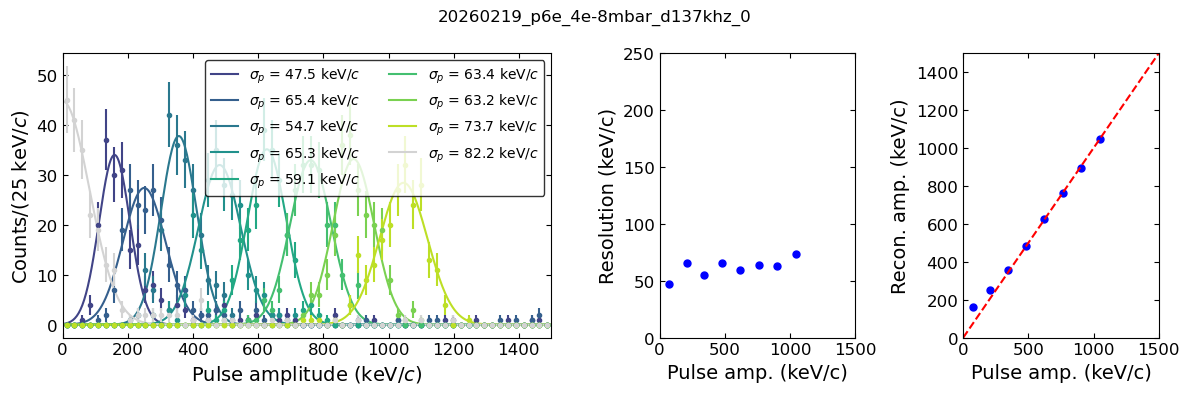

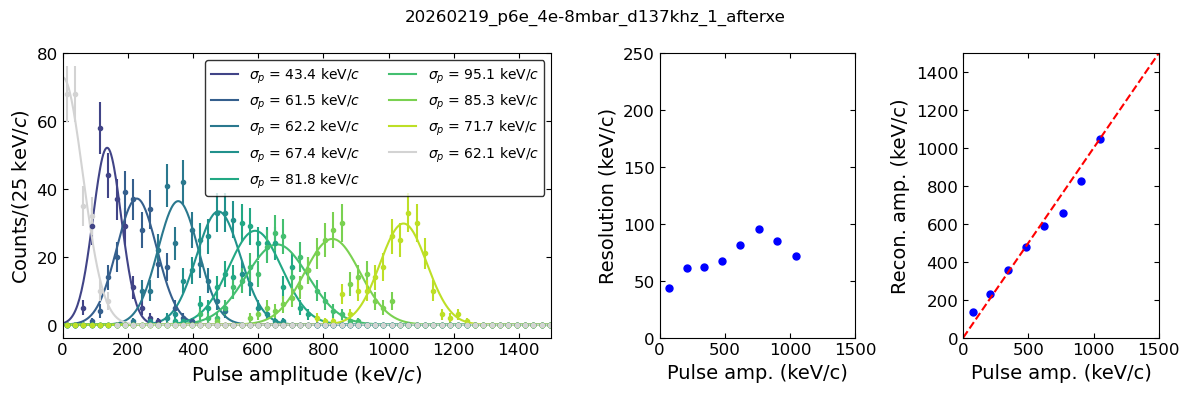

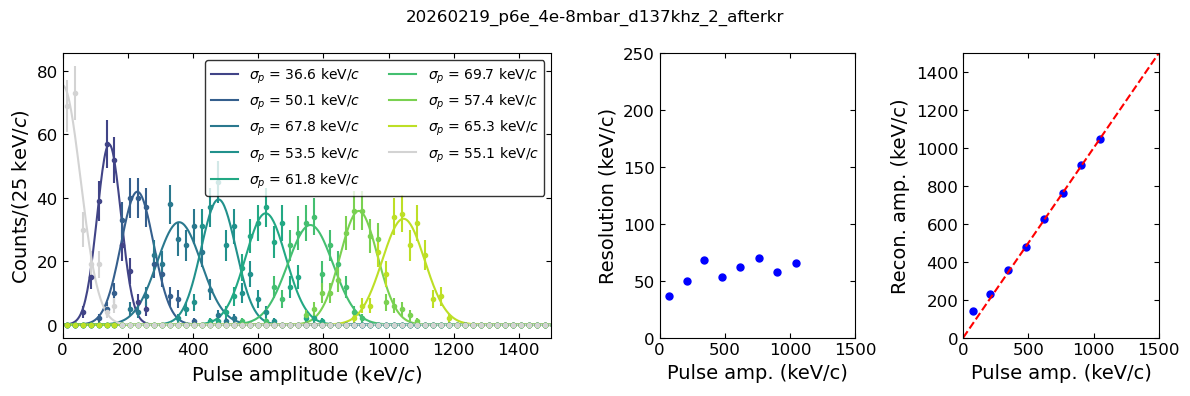

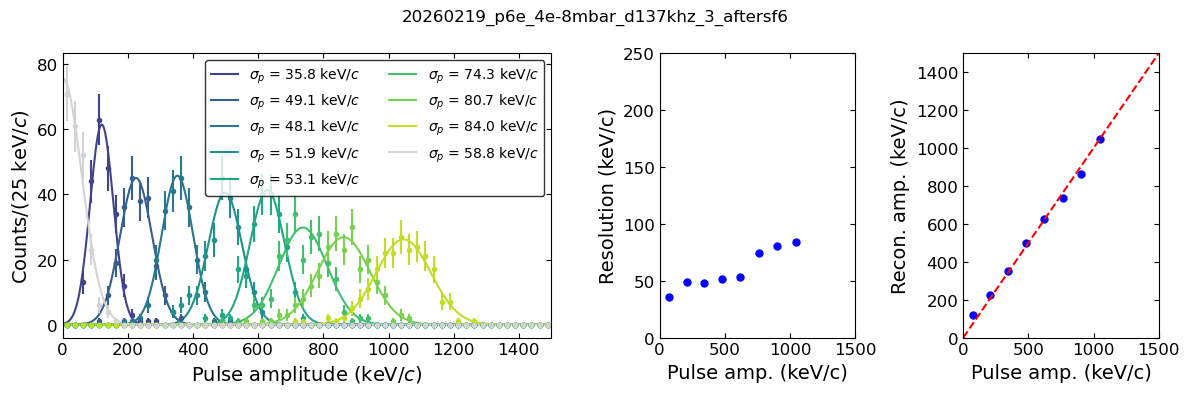

In [7]:
# pulse_amp = np.asarray([99, 279, 456, 643, 824, 1018, 1202, 1395]) * 6/8
pulse_amp = np.asarray([74, 209, 342, 482, 618, 764, 901, 1046])

amps_all = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
amps_noise_all = [amps_noise_0, amps_noise_1, amps_noise_2, amps_noise_3]

amp2kev_bin = 8563.264990921774
for j in range(len(amps_all)):
    bins = np.arange(0, 3000, 25) / amp2kev_bin
    hhs, bcs, gps = utils.fit_amps_gaus(amps_all[j], bins=bins, noise=False, return_bins=False)
    hhs_noise, bcs_noise, gps_noise = utils.fit_amps_gaus([amps_noise_all[j]], bins=bins, noise=True, return_bins=False)

    amp2kevs = pulse_amp / np.asarray(gps).T[1]
    amp2kev = amp2kevs[-1]

    print('amp2keV', amp2kev)
    print('Fitted sigma:', np.asarray(gps).T[2]*amp2kev, 'keV/c')

    xx = np.linspace(0, np.max(bcs[0]), 1000)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), width_ratios=[2.5, 1, 1])

    cmap = plt.colormaps.get_cmap('viridis')
    colors = cmap(np.linspace(0.2, 0.9, 8))
    for i in range(pulse_amp.size):
        axes[0].errorbar(bcs[i]*amp2kev, hhs[i], yerr=np.sqrt(hhs[i]), fmt='.', color=colors[i])
        axes[0].plot(xx*amp2kev, utils.gauss(xx, *gps[i]), label=fr'$\sigma_p$ = {gps[i][2]*amp2kev:.1f} keV/$c$', color=colors[i])

    axes[0].errorbar(bcs_noise[0]*amp2kev, hhs_noise[0], yerr=np.sqrt(hhs_noise[0]), fmt='.', color='lightgrey')
    axes[0].plot(xx*amp2kev, utils.gauss_zero(xx, *gps_noise[0]), label=fr'$\sigma_p$ = {gps_noise[0][1]*amp2kev:.1f} keV/$c$', color='lightgrey')

    print('Noise level', gps_noise[0][1], 'arb. amplitude')
    print('Noise level', gps_noise[0][1]*amp2kev, 'keV/c')

    axes[0].set_xlim(0, 1500)
    axes[0].legend(edgecolor='k', ncol=2, fontsize=10)
    axes[0].set_xlabel(r'Pulse amplitude (keV/$c$)')
    axes[0].set_ylabel(r'Counts/(25 keV/$c$)')

    # if j == 4:
    #     axes[0].set_title(f'Combined dataset')
    #     axes[0].set_ylim(0, 320)
    # else:
    #     axes[0].set_title(f'{datasets[j]}')
    #     axes[0].set_ylim(0, 80)

    axes[1].plot(pulse_amp, np.asarray(gps).T[2]*amp2kev, 'b.', markersize=10)
    axes[1].set_xlim(0, 1500)
    axes[1].set_ylim(0, 250)
    axes[1].set_xlabel('Pulse amp. (keV/c)')
    axes[1].set_ylabel('Resolution (keV/c)')
    # axes[1].plot(np.linspace(0, 1500, 50), np.full(50, gps_noise[0][1]*amp2kev_all), 'k--')

    axes[2].plot(pulse_amp, np.asarray(gps).T[1]*amp2kev, 'b.', markersize=10)
    axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
    axes[2].set_xlim(0, 1500)
    axes[2].set_ylim(0, 1500)
    axes[2].set_xlabel('Pulse amp. (keV/c)')
    axes[2].set_ylabel('Recon. amp. (keV/c)')

    fig.suptitle(datasets_all[j])
    fig.tight_layout()

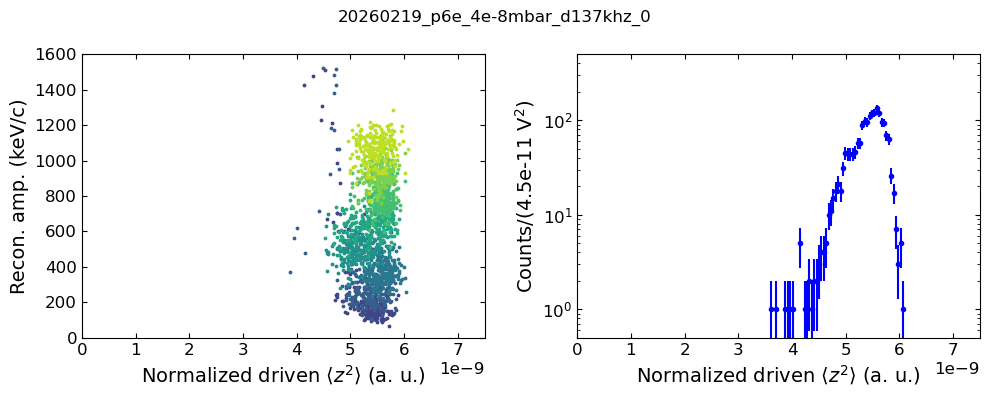

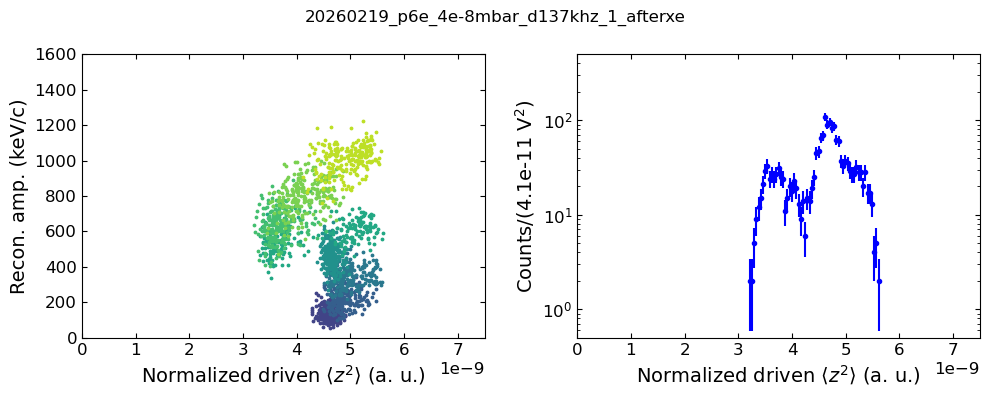

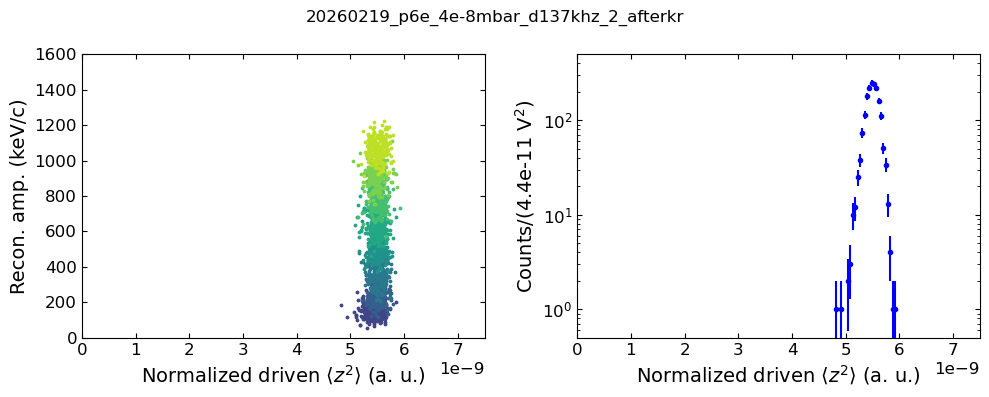

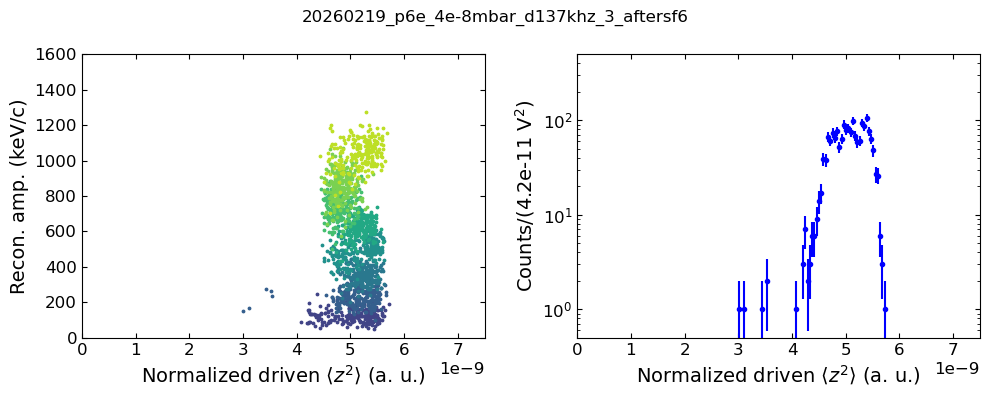

In [8]:
drive_freq = 137000
ref_freq = 48500

drive_areas = [drive_area_all_0, drive_area_all_1, drive_area_all_2, drive_area_all_3]
amps_lists  = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
f_res_lists = [f_res_all_0, f_res_all_1, f_res_all_2, f_res_all_3]

for dataset, drive_area, amps, f_res in zip(datasets_all, drive_areas, amps_lists, f_res_lists):
    fig, axes, bc, hh = plot_monitoring(dataset, drive_area, amps, f_res, drive_freq, ref_freq, amp2kev)
    for ax in axes:
        ax.set_xlim(0, 0.75e-8)


In [9]:
def get_good_amps(amps_all, pulse_shapes_all, indices_in_win, drive_area_all, f_res_all, drive_freq, ref_freq, threshold):
    good_amps, good_pulses, good_indices = [], [], []
    for i, drive_area in enumerate(drive_area_all):
        normalized_drive_area = drive_area * (f_res_all[i]**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        good_amps.append(amps_all[i][normalized_drive_area > threshold])
        good_pulses.append(pulse_shapes_all[i][normalized_drive_area > threshold])
        good_indices.append(indices_in_win[i][normalized_drive_area > threshold])
    return good_amps, good_pulses, good_indices


In [10]:
drive_freq = 137000
ref_freq = 48500
threshold = 4.5e-9

drive_areas = [drive_area_all_0, drive_area_all_1, drive_area_all_2, drive_area_all_3]
amps_lists  = [amps_all_0, amps_all_1, amps_all_2, amps_all_3]
pulse_shapes_lists = [pulse_shapes_all_0, pulse_shapes_all_1, pulse_shapes_all_2, pulse_shapes_all_3]
indices_lists = [indices_0, indices_1, indices_2, indices_3]
f_res_lists = [f_res_all_0, f_res_all_1, f_res_all_2, f_res_all_3]

good_amps_all_datasets = []
good_pulses_all_datasets = []
good_indices_all_datasets = []

for amps, pulses, indices, drive_area, f_res in zip(amps_lists, pulse_shapes_lists, indices_lists, drive_areas, f_res_lists):
    good_amps, good_pulses, good_indices = get_good_amps(amps, pulses, indices, drive_area, f_res, drive_freq, ref_freq, threshold)
    good_amps_all_datasets.append(good_amps)
    good_pulses_all_datasets.append(good_pulses)
    good_indices_all_datasets.append(good_indices)

for j, dataset in enumerate(datasets_all):
    counts = [len(g) for g in good_amps_all_datasets[j]]
    total_before = sum(len(amps_lists[j][i]) for i in range(8))
    total_after = sum(counts)
    print(f'{dataset}: {total_after}/{total_before} windows pass ({100*total_after/total_before:.1f}%)')

# Collect all the amplitudes/pulse shapes/indices into arrays
_good_amps_all_datasets = []
_good_pulse_shape_all_datasets = []
_good_indices_all_datasets = []
for i in range(8):
    _amps = np.concatenate([good_amps_all_datasets[j][i] for j in range(4)])
    _pulses = np.concatenate([good_pulses_all_datasets[j][i] for j in range(4)], axis=0)
    _indices = np.concatenate([good_indices_all_datasets[j][i] for j in range(len(datasets_all))], axis=0)
    _good_amps_all_datasets.append(_amps)
    _good_pulse_shape_all_datasets.append(_pulses)
    _good_indices_all_datasets.append(_indices)

good_amps_all_datasets = _good_amps_all_datasets
good_pulse_shape_all_datasets = _good_pulse_shape_all_datasets
good_indices_all_datasets = _good_indices_all_datasets


20260219_p6e_4e-8mbar_d137khz_0: 1740/1761 windows pass (98.8%)
20260219_p6e_4e-8mbar_d137khz_1_afterxe: 1155/1762 windows pass (65.6%)
20260219_p6e_4e-8mbar_d137khz_2_afterkr: 1763/1763 windows pass (100.0%)
20260219_p6e_4e-8mbar_d137khz_3_aftersf6: 1716/1760 windows pass (97.5%)


amp2keV: 8470.15906897578


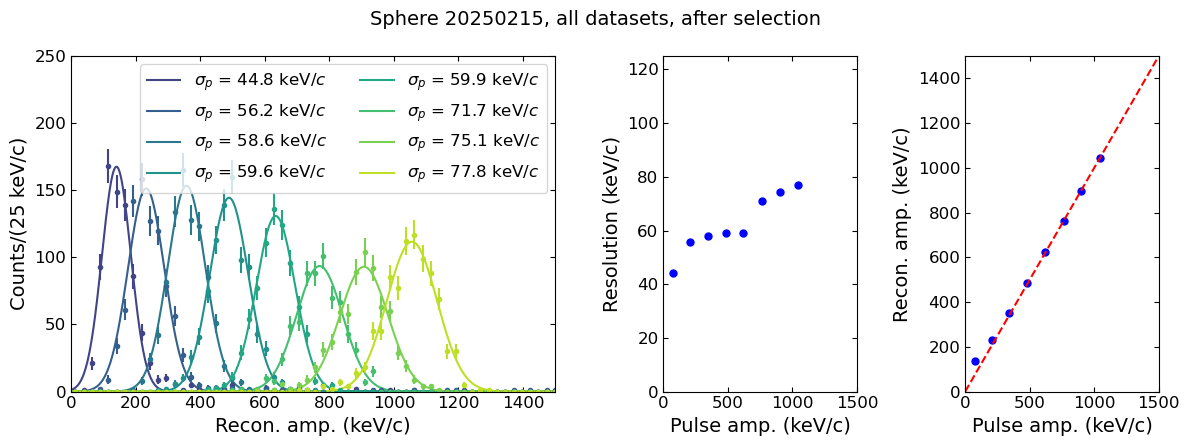

In [11]:
from scipy.optimize import curve_fit

def model_func(x, a):
    return a * x

amp2kev_bin = 8363
bins = np.arange(0, 3000, 25) / amp2kev_bin
pulse_amp = np.asarray([74, 209, 342, 482, 618, 764, 901, 1046])

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), width_ratios=[2.5, 1, 1])
hhs_good, bcs_good, gps_good = utils.fit_amps_gaus(good_amps_all_datasets, bins=bins, noise=False, return_bins=False)

xx = np.linspace(0, np.max(bcs[0]), 1000)
for i in range(8):
    axes[0].errorbar(bcs_good[i]*amp2kev, hhs_good[i], yerr=np.sqrt(hhs_good[i]), fmt='.', color=colors[i])
    axes[0].plot(xx*amp2kev, utils.gauss(xx, *gps_good[i]), label=fr'$\sigma_p$ = {gps_good[i][2]*amp2kev:.1f} keV/$c$', color=colors[i])

amp2kevs = pulse_amp / np.asarray(gps_good).T[1]
amp2kev = curve_fit(model_func, np.asarray(gps_good).T[1][2:], pulse_amp[2:])[0][0]
print(f'amp2keV: {amp2kev}')

axes[0].legend(ncol=2)
axes[0].set_xlim(0, 1500)
axes[0].set_ylim(0, 250)
axes[0].set_xlabel('Recon. amp. (keV/c)')
axes[0].set_ylabel('Counts/(25 keV/c)')

axes[1].plot(pulse_amp, np.asarray(gps_good).T[2]*amp2kev, 'b.', markersize=10)
axes[1].set_xlim(0, 1500)
axes[1].set_ylim(0, 125)
axes[1].set_xlabel('Pulse amp. (keV/c)')
axes[1].set_ylabel('Resolution (keV/c)')

axes[2].plot(pulse_amp, np.asarray(gps_good).T[1]*amp2kev, 'b.', markersize=10)
axes[2].plot(np.linspace(0, 1500, 50), np.linspace(0, 1500, 50), 'r--')
axes[2].set_xlim(0, 1500)
axes[2].set_ylim(0, 1500)
axes[2].set_xlabel('Pulse amp. (keV/c)')
axes[2].set_ylabel('Recon. amp. (keV/c)')

fig.suptitle('Sphere 20250215, all datasets, after selection', fontsize=14)
fig.tight_layout()

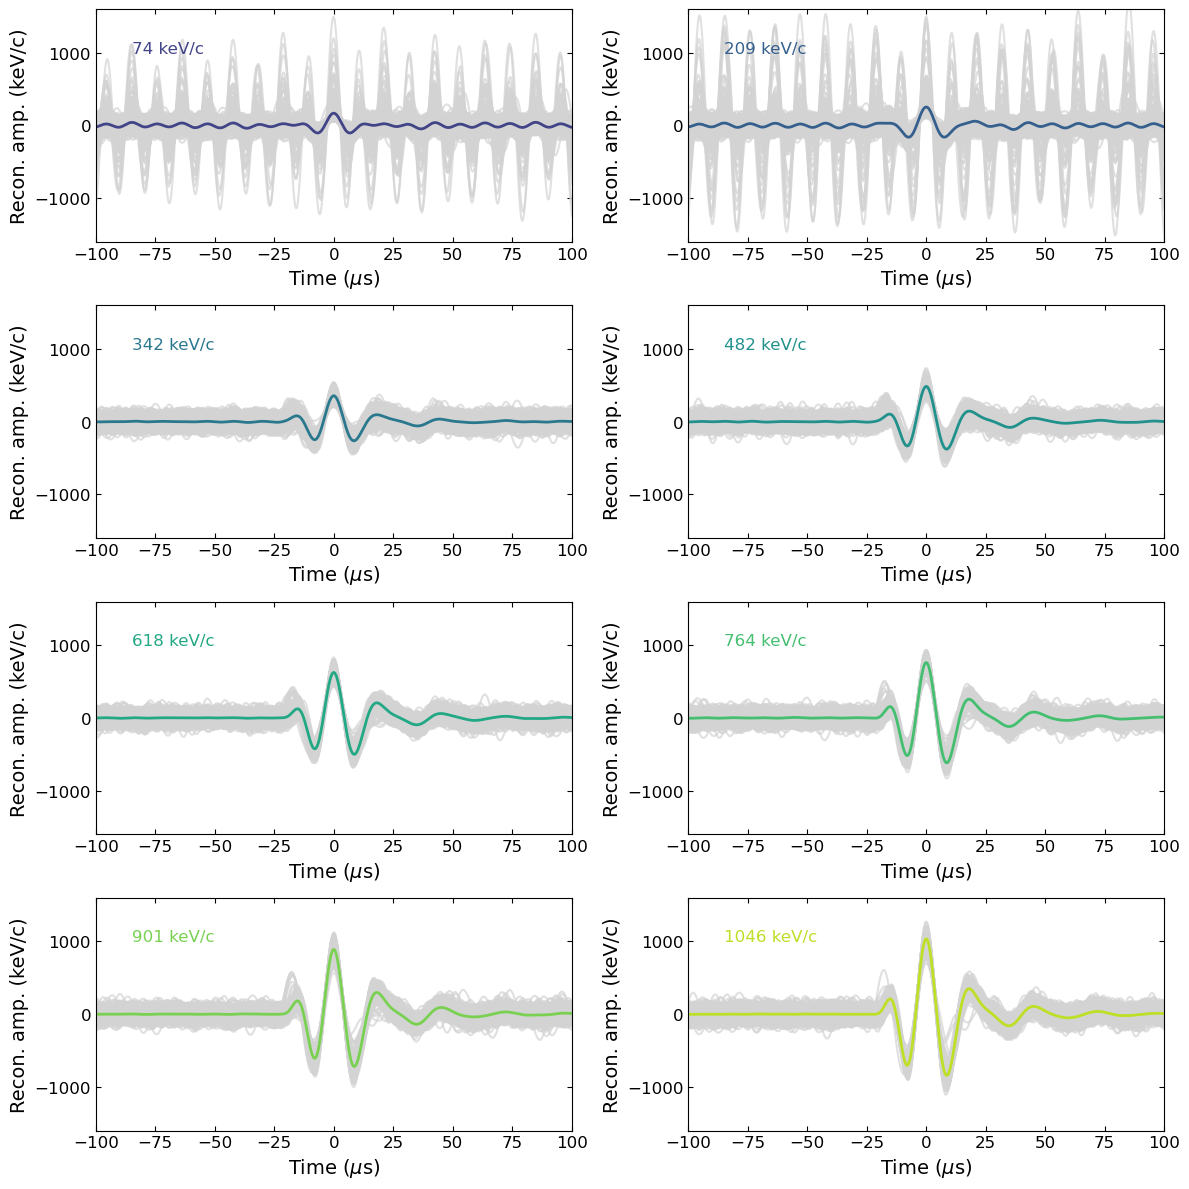

In [12]:
# Form templates by averaging
pulse_shape_template_all = [np.mean(pulses, axis=0) for pulses in good_pulse_shape_all_datasets]

tt = 200e-9 * np.arange(3000)

fig, axes = plt.subplots(4 ,2, figsize=(12, 12))
for i, good_pulse in enumerate(good_pulse_shape_all_datasets):
    ax = axes.flatten()[i]
    
    for j in range(good_pulse.shape[0]):
        ax.plot(tt/1e-6-300, amp2kev*good_pulse[j], color='lightgray', alpha=0.7)

    ax.plot(tt/1e-6 - 300, amp2kev*np.mean(good_pulse, axis=0), color=colors[i], linewidth=2)

    ax.set_xlabel(r'Time ($\mu$s)')
    ax.set_ylabel(r'Recon. amp. (keV/c)')

    ax.text(-85, 1000, f'{pulse_amp[i]} keV/c', fontsize=12, color=colors[i])
    ax.set_xlim(-100, 100)
    ax.set_ylim(-1600, 1600)

fig.tight_layout()

In [18]:
# Save the averaged calibraiton waveform as template
np.savez(
    r'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/pulse_calibration/sphere_20260215_pulse_shape_template_combined.npz',
    ps_2_5v=pulse_shape_template_all[0],
    ps_5v=pulse_shape_template_all[1],
    ps_7_5v=pulse_shape_template_all[2],
    ps_10v=pulse_shape_template_all[3],
    ps_12_5v=pulse_shape_template_all[4],
    ps_15v=pulse_shape_template_all[5],
    ps_17_5v=pulse_shape_template_all[6],
    ps_20v=pulse_shape_template_all[7],
    pulse_amp_kev=pulse_amp,
    amp2kev=amp2kev,
)

#### Calculate the chi2 and efficiency curve

In [13]:
def get_normalized_template(sphere, bounds=(1250, 1750), downsampled=False):
    pulse_shape_file = np.load(rf'/Users/yuhan/work/nanospheres/gas_collisiions/data_processed/pulse_calibration/{sphere}_pulse_shape_template_combined.npz')
    pulse_shape_template = pulse_shape_file['ps_20v']

    normalized_template = pulse_shape_template / np.max(pulse_shape_template)

     # Take the central values around the peak
    ret = normalized_template[bounds[0]:bounds[1]]

    # Downsample to 500 kHz (so the 200 us template has 100 indices)
    if downsampled:
        ret_downsampled = decimate(ret, 10)
        return ret_downsampled / np.max(ret_downsampled)
    else:
        return ret

def calc_chisquares_pulse(pulse_shapes, normalized_template, bounds, sigma_amp):
    amp_idx = 1500

    ret = np.empty(pulse_shapes.shape[0])
    for i, pulse_shape in enumerate(pulse_shapes):
        amp = pulse_shape[amp_idx]

        waveform = pulse_shape[bounds[0] : bounds[1]]
        # Amplitude can be negative so no need to adjust for polarity
        template_scaled = amp * normalized_template

        # Sigma should be in amplitude (not keV)
        ret[i] = np.sum( ((waveform - template_scaled)/sigma_amp)**2 )
    return ret

In [14]:
sphere = 'sphere_20260215'
normalized_template = get_normalized_template(sphere, bounds=(1250, 1750), downsampled=False)

sigma_p_amp = 60 / amp2kev
chi2_pulse_all = []
for i, good_pulses in enumerate(good_pulse_shape_all_datasets):
    chi2 = calc_chisquares_pulse(good_pulses, normalized_template, (1250, 1750), sigma_p_amp)
    chi2_pulse_all.append(chi2)

Text(0.5, 1.0, 'sphere_20260215, all calibration')

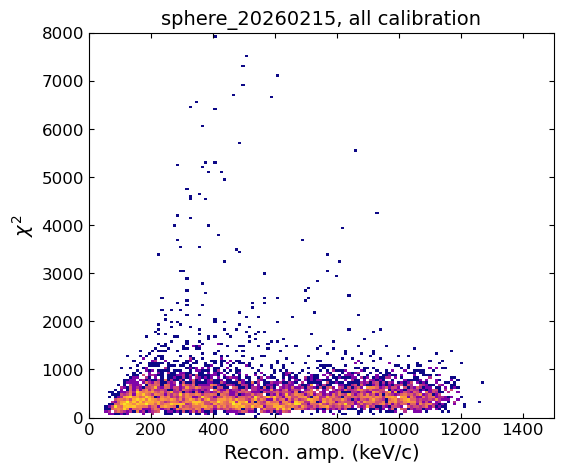

In [15]:
import matplotlib.colors as colors

xbins = np.linspace(0, 2000, 200)
ybins = np.linspace(0, 10000, 200)

_good_amps_all_datasets = np.concatenate(good_amps_all_datasets)
_chi2_all_datasets = np.concatenate(chi2_pulse_all)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

hh, _, _ = np.histogram2d(x=np.abs(_good_amps_all_datasets)*amp2kev, y=_chi2_all_datasets, bins=(xbins, ybins))
pc = ax.pcolormesh(xbins, ybins, hh.T, norm=colors.LogNorm(), cmap='plasma')

ax.set_ylim(0, 8000)
ax.set_xlim(0, 1500)
ax.set_xlabel(r'Recon. amp. (keV/c)', fontsize=14)
ax.set_ylabel(r'$\chi^2$', fontsize=14)
ax.set_title(f'{sphere}, all calibration')

Average accepctance ratio by the chi2 cut: 0.83 +- 0.01


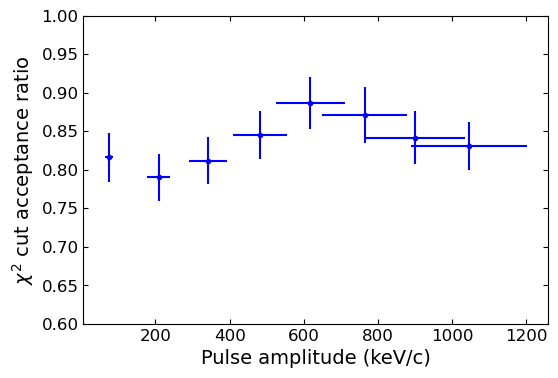

In [38]:
#### Check the fraction of calibration pulses accepted by the chi2 cut
chi2_threshold = 700

frac_accepted, frac_accepted_err = [], []
total_accepted, all_pulses = 0, 0
for chi2 in chi2_pulse_all:
    frac_accepted.append(np.sum(chi2 < chi2_threshold) / chi2.size)
    frac_accepted_err.append(np.sqrt(np.sum(chi2 < chi2_threshold)) / chi2.size)

    total_accepted += np.sum(chi2 < chi2_threshold)
    all_pulses += chi2.size

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(pulse_amp, frac_accepted, xerr=pulse_amp*0.15, yerr=frac_accepted_err, fmt='.', color='b')
ax.set_ylim(0.6, 1)
ax.set_ylabel(r'$\chi^2$ cut acceptance ratio')
ax.set_xlabel('Pulse amplitude (keV/c)')

print(f'Average accepctance ratio by the chi2 cut: {total_accepted/all_pulses:.2f} +- {np.sqrt(total_accepted)/all_pulses:.2f}')

#### Signal efficiency by counting calibration pulses based on timing

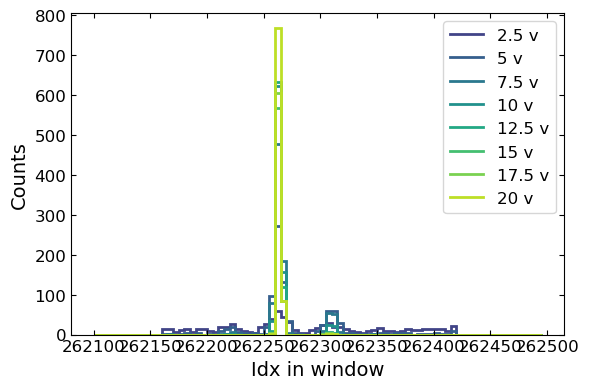

In [24]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0.2, 0.9, 8))

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.arange(262100, 262500, 5)
bc = 0.5 * (bins[1:] + bins[:-1])
hhs_all = []
for i in range(8):
    hh, _ = np.histogram(good_indices_all_datasets[i], bins=bins)
    hhs_all.append(hh)
    ax.stairs(hh, edges=bins, color=colors[i], label=f'{voltages[i]} v', linewidth=2)

ax.set_xlabel('Idx in window')
ax.set_ylabel('Counts')
ax.legend()
fig.tight_layout()

In [23]:
from scipy.special import erf
def func_eff(x, z, f):
    return 0.5 * erf((x - z) * f) + 0.5

good_recon_idx = np.asarray([31, 32, 33, 40, 41, 42])
effs_all, effs_err_all = np.empty(8), np.empty(8)
for i in range(8):
    effs_all[i] = np.sum(hhs_all[i][good_recon_idx] / np.sum(hhs_all[i]))
    effs_err_all[i] = np.sqrt(np.sum(hhs_all[i][good_recon_idx])) / np.sum(hhs_all[i])

popt, pcov = curve_fit(func_eff, pulse_amp, effs_all, sigma=effs_err_all, p0=[60, 0.001], maxfev=5000)

Efficiency coefficients: [1.39007903e+02 6.66802235e-03]


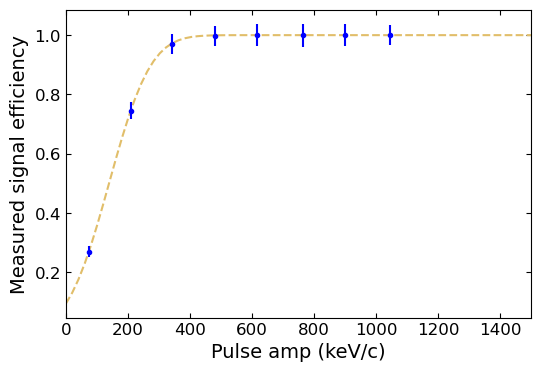

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))

xx = np.linspace(0, 2000, 100)
ax.plot(xx, func_eff(xx, *popt), '--',label='Error function fit', color='#E1BE6A')

ax.errorbar(pulse_amp, effs_all, yerr=effs_err_all, color='b', fmt='.')

ax.set_xlim(0, 1500)

ax.set_xlabel('Pulse amp (keV/c)')
ax.set_ylabel(r'Measured signal efficiency')

print(f'Efficiency coefficients: {popt}')